In [19]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from dbfread import DBF

import plotly.graph_objects as go
import os

# tratar fuentes por año

In [3]:
### Análisis de datos 2024

# Ruta del archivo csv
ruta_archivo = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\Municipios\efipem_municipal_anual_tr_cifra_2024.csv"
ruta_archivo_CDMX = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\CDMX\efipem_demarcaciones_cdmx_tr_cifra_2024.csv"

# Cargar archivos en un DataFrame
df_1 = pd.read_csv(ruta_archivo, dtype={'CVE_ENT': str, 'CVE_MUN': str})
df_2 = pd.read_csv(ruta_archivo_CDMX, dtype={'CVE_ENT': str, 'CVE_MUN': str})

# #renombrar columna alcaldías
# df_2 = df_2.rename(columns={'CVE_MUN': 'CVE_MUN'}, inplace=True)

df = pd.DataFrame(pd.concat([df_1, df_2], ignore_index=True))

# Homologación de ID rural - CVEGEO
def homologate_mun_id(row):
    return f"{row['CVE_ENT']}{row['CVE_MUN']}"

df['CVEGEO'] = df.apply(homologate_mun_id, axis=1)

# Actualizar valores sin información de "null" a 0
df = df.fillna(0)

# Filtrar por variables de egresos
df_egresos = df[df['TEMA'] == 'Egresos']

# Filtrar por variables de ingresos
df_ingresos = df[df['TEMA'] == 'Ingresos']

#Filtrar Partidas
partidas = ['Tema', 'Capítulo']

def filtrar_partidas_gpkg(dataframe, partidas):
    return dataframe[(dataframe['CATEGORIA'].isin(partidas))]

df_egresos = filtrar_partidas_gpkg(df_egresos, partidas)
df_ingresos = filtrar_partidas_gpkg(df_ingresos, partidas)

# Pivotar la tabla para obtener variables como columnas en cada hoja
df_egresos_pivot = df_egresos.pivot_table(index=['CVEGEO', 'CVE_ENT', 'CVE_MUN'], columns='DESCRIPCION_CATEGORIA', values='VALOR').reset_index()
df_ingresos_pivot = df_ingresos.pivot_table(index=['CVEGEO', 'CVE_ENT', 'CVE_MUN'], columns='DESCRIPCION_CATEGORIA', values='VALOR').reset_index()

# Renombrar las columnas resultantes en cada hoja
df_egresos_pivot.columns.name = None
df_ingresos_pivot.columns.name = None

# Actualizar valores sin información de "null" a 0
df_egresos_pivot = df_egresos_pivot.fillna(0)
df_ingresos_pivot = df_ingresos_pivot.fillna(0)

#guardar en csv
def save_to_csv(dataframe, filename):
    dataframe.to_csv(filename, index=False)

df_egresos_salida = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\Tratados\2024\Egresos 24.csv"
df_ingresos_salida = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\Tratados\2024\Ingresos 24.csv"

save_to_csv(df_egresos_pivot, df_egresos_salida)
save_to_csv(df_ingresos_pivot, df_ingresos_salida)

# crear relaciones de flujos

In [46]:
df_egresos_salida = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\Tratados\2024\Egresos 24.csv"
df_ingresos_salida = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\Tratados\2024\Ingresos 24.csv"

ruta_dicc = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\clasificacion_finanzas_empty.csv"
ruta_dicc_pond = r"C:\Users\alflo\Desktop\GIS\Finanzas municipales\clasificacion_finanzas.csv"

In [29]:
# Cargar archivos en un DataFrame
df_egresos = pd.read_csv(df_egresos_salida, dtype={'CVEGEO': str,'CVE_ENT': str, 'CVE_MUN': str})
df_ingresos = pd.read_csv(df_ingresos_salida, dtype={'CVEGEO': str,'CVE_ENT': str, 'CVE_MUN': str})

## creación de diccionario

In [8]:
df_ingresos.columns

Index(['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'Aportaciones federales y estatales',
       'Aprovechamientos', 'Contribuciones de Mejoras',
       'Cuotas y Aportaciones de Seguridad Social', 'Derechos',
       'Financiamiento', 'Impuestos', 'Otros ingresos',
       'Participaciones federales', 'Productos', 'Total de ingresos'],
      dtype='object')

In [10]:
ingresos_cols = ['Aportaciones federales y estatales','Aprovechamientos','Contribuciones de Mejoras',
                 'Cuotas y Aportaciones de Seguridad Social','Derechos','Financiamiento','Impuestos',
                 'Otros ingresos','Participaciones federales','Productos']

egresos_cols = ['Bienes muebles, inmuebles e intangibles','Deuda pública','Disponibilidad final',
                'Inversión pública','Materiales y suministros','Otros egresos','Servicios generales',
                'Servicios personales','Transferencias, asignaciones, subsidios y otras ayudas']

In [41]:
clasificacion = pd.DataFrame({
    "categoria_original": ingresos_cols + egresos_cols,
    "grupo_n1": "",
    "grupo_n2": "",
    "tipo": (
        ["ingreso"] * len(ingresos_cols) +
        ["egreso"] * len(egresos_cols)
    )
})

clasificacion.to_csv(ruta_dicc, index=False, encoding="utf-8-sig")

## Creación de gráficas individuales

### funciones

In [77]:
def construir_flujos(row):

    flujos = []

    for _, meta in clasif.iterrows():

        categoria = meta["categoria_original"]
        n1 = meta["grupo_n1"]
        n2 = meta["grupo_n2"]
        tipo = meta["tipo"]

        valor = row[categoria]

        if valor <= 0:
            continue

        # INGRESOS
        if tipo == "ingreso":

            if n2 != "":
                flujos.append({"source": categoria, "target": n2, "value": valor})
                flujos.append({"source": n2, "target": n1, "value": valor})

            elif n1 != "":
                flujos.append({"source": categoria, "target": n1, "value": valor})

        # EGRESOS
        else:

            if n2 != "":
                flujos.append({"source": n1, "target": n2, "value": valor})
                flujos.append({"source": n2, "target": categoria, "value": valor})

            elif n1 != "":
                flujos.append({"source": n1, "target": categoria, "value": valor})

    # ========
    # INGRESOS -> BALANCE
    # ========

    for grupo in clasif.loc[clasif["tipo"] == "ingreso", "grupo_n1"].unique():

        if grupo == "":
            continue

        categorias = clasif.loc[
            (clasif["tipo"] == "ingreso") &
            (clasif["grupo_n1"] == grupo),
            "categoria_original"
        ]

        total = row[categorias].sum()

        if total > 0:
            flujos.append({"source": grupo, "target": "Balance municipal", "value": total})

    # ========
    # BALANCE -> EGRESOS
    # ========

    for grupo in clasif.loc[clasif["tipo"] == "egreso", "grupo_n1"].unique():

        if grupo == "":
            continue

        categorias = clasif.loc[
            (clasif["tipo"] == "egreso") &
            (clasif["grupo_n1"] == grupo),
            "categoria_original"
        ]

        total = row[categorias].sum()

        if total > 0:
            flujos.append({"source": "Balance municipal", "target": grupo, "value": total})

    flujos = pd.DataFrame(flujos)

    flujos = (
        flujos
        .groupby(["source", "target"], as_index=False)
        .agg({"value": "sum"})
    )

    return flujos

In [129]:
def crear_sankey(df_flujos, titulo="Sankey"):

    labels = list(pd.unique(df_flujos[['source','target']].values.ravel()))

    label_dict = {label:i for i,label in enumerate(labels)}

    source = df_flujos['source'].map(label_dict)
    target = df_flujos['target'].map(label_dict)
    value  = df_flujos['value']

    # COLORES
    
    color_dict = {

        # ingresos propios
        "Impuestos":"#2E86AB",
        "Derechos":"#2E86AB",
        "Productos":"#2E86AB",
        "Aprovechamientos":"#2E86AB",
        "Contribuciones de Mejoras":"#2E86AB",
        "Ingresos tributarios":"#2E86AB",
        "Ingresos no tributarios":"#2E86AB",
        "Autonomía fiscal":"#2E86AB",

        # federales
        "Participaciones federales":"#7DCEA0",
        "Aportaciones federales y estatales":"#7DCEA0",
        "Participaciones":"#7DCEA0",
        "Aportaciones":"#7DCEA0",
        "Dependencia federal":"#7DCEA0",

        # financiamiento
        "Financiamiento":"#F5B041",
        "Endeudamiento":"#F5B041",

        # balance
        "Balance municipal":"#7F8C8D",

        # gasto corriente
        "Gasto corriente":"#EC7063",
        "Operación":"#EC7063",
        "Servicios personales":"#EC7063",
        "Servicios generales":"#EC7063",
        "Materiales y suministros":"#EC7063",
        "Transferencias":"#EC7063",
        "Transferencias, asignaciones, subsidios y otras ayudas":"#EC7063",

        # capital
        "Gasto de capital":"#AF7AC5",
        "Inversión":"#AF7AC5",
        "Activos":"#AF7AC5",
        "Inversión pública":"#AF7AC5",
        "Bienes muebles, inmuebles e intangibles":"#AF7AC5",

        # deuda
        "Obligaciones financieras":"#566573",
        "Servicio de deuda":"#566573",
        "Deuda pública":"#566573",

        # disponibilidad
        "Balance financiero":"#48C9B0",
        "Disponibilidad final":"#48C9B0"
    }

    node_colors = [color_dict.get(label,"#D5D8DC") for label in labels]

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(label=labels,color=node_colors,pad=18,thickness=20,line=dict(width=0.5,color="rgba(50,50,50,0.2)")),
        link=dict(source=source,target=target,value=value,color="rgba(120,120,120,0.25)")
    )])

    fig.update_layout(
        width=900, height=900,
        title_text=titulo,
        font=dict(
            family="Catamaran Light",
            size=24
        )
    )

    return fig

### graficar

In [42]:
# Combinar df
df_total = (df_ingresos.merge(df_egresos, on=["CVEGEO","CVE_ENT","CVE_MUN"], suffixes=("_ing", "_egr")))

In [53]:
# Seleccionar mun
mun = df_total.loc[df_total["CVEGEO"] == "11007"]

In [ ]:
# Obtener niveles de diccionario
clasif = pd.read_csv(ruta_dicc_pond)

n1 = dict(zip(clasif["categoria_original"], clasif["grupo_n1"]))

n2 = dict(zip(clasif["categoria_original"], clasif["grupo_n2"]))

tipo = dict(zip(clasif["categoria_original"], clasif["tipo"]))

# rellenar vacios
clasif["grupo_n1"] = clasif["grupo_n1"].fillna("")
clasif["grupo_n2"] = clasif["grupo_n2"].fillna("")

In [ ]:
# Crear flujos
flujos = construir_flujos(row)

In [134]:
# Exportar flujos
flujos_salida = fr"C:\Users\alflo\Desktop\URBAN DATA LAB\2605 Ingresos egresos\Flujos x mun\2024_11007.csv"

flujos.to_csv(flujos_salida, index=False)

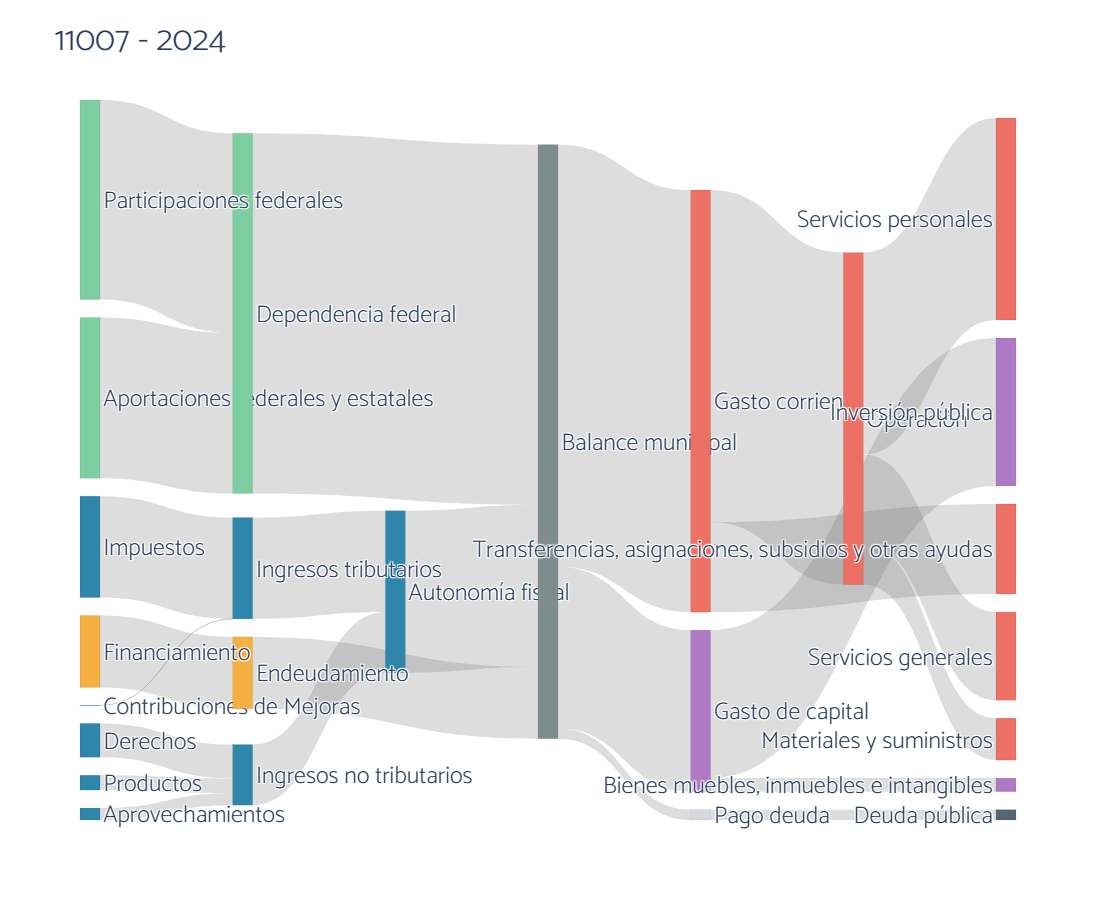

In [130]:
#Graficar
fig = crear_sankey(flujos,f"{row['CVEGEO']} - 2024")

fig.show()